In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import optuna
from src.preprocessing import process_dataframe
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from src.visualization import plot_forecast
from src.models.rnn.rnn_regressor import RNNRegressor
from src.models.rnn.train_rnn_recursive import train_rnn_recursive
from src.models.rnn.predict import get_full_predict
from src.evaluation import evaluate, evaluate_by_depth

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [4]:
df_train_full = process_dataframe(df_train_full)
df_train = process_dataframe(df_train)
df_val = process_dataframe(df_val)
df_test = process_dataframe(df_test)

In [5]:
target_cols = ['48-1 (0)','48-1 (0,5)', '48-1 (1)', '48-1 (1,5)','48-1 (2)', '48-1 (2,5)', '48-1 (3)', 
               '48-1 (3,5)', '48-1 (4)', '48-1 (4,5)', '48-1 (5)', '48-1 (6)', '48-1 (7)', '48-1 (8)', 
               '48-1 (9)', '48-1 (10)']
features_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 
                 'day_of_year_cos', 'is_anomaly']
lags_length = 14

df_train_full = df_train_full[features_cols + target_cols]
df_train = df_train[features_cols + target_cols]
df_val = df_val[features_cols + target_cols]
df_test = df_test[features_cols + target_cols]

In [6]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

train_features_scaled = feature_scaler.fit_transform(df_train[features_cols])
train_target_scaled = target_scaler.fit_transform(df_train[target_cols])

train_scaled = np.hstack((train_features_scaled, train_target_scaled))

val_start = df_train[-lags_length:]
df_full_val = pd.concat([val_start, df_val])

val_features_scaled = feature_scaler.transform(df_full_val[features_cols])
val_target_scaled = target_scaler.transform(df_full_val[target_cols])

val_scaled = np.hstack((val_features_scaled, val_target_scaled))

In [7]:
full_feature_scaler = StandardScaler()
full_target_scaler = StandardScaler()

full_train_features_scaled = full_feature_scaler.fit_transform(df_train_full[features_cols])
full_train_target_scaled = full_target_scaler.fit_transform(df_train_full[target_cols])

full_train_scaled = np.hstack((full_train_features_scaled, full_train_target_scaled))

In [8]:
def create_sequences(data, target_start_index, lags_length):
    X, y = [], []
    for i in range(len(data) - lags_length):
        X.append(data[i : i + lags_length])
        y.append(data[i + lags_length, target_start_index:])
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)

target_start_index = len(features_cols)

X_train, y_train = create_sequences(train_scaled, target_start_index, lags_length)
X_val, y_val = create_sequences(val_scaled, target_start_index, lags_length)
X_full_train, y_full_train = create_sequences(full_train_scaled, target_start_index, lags_length)

In [9]:
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)
full_train_loader = DataLoader(TensorDataset(X_full_train, y_full_train), batch_size=batch_size)

In [10]:
val_future_features_tensor = torch.tensor(
    val_scaled[lags_length:, :len(features_cols)], 
    dtype=torch.float32
).to(device)

input_size = train_scaled.shape[1]
output_size = len(target_cols)
criterion = nn.MSELoss()

def objective(trial):
    hidden_size = trial.suggest_int('hidden_size', 16, 160, step=16)
    num_layers = trial.suggest_int('num_layers', 2, 5)
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    
    model_trial = RNNRegressor(
        input_size,
        hidden_size,
        num_layers,
        output_size,
        dropout=dropout,
        rnn_type='gru'
    ).to(device)
    optimizer_trial = optim.AdamW(model_trial.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_trial,
        mode='min',
        factor=0.5,
        patience=5,
        min_lr=1e-6
    )

    model_trial, history = train_rnn_recursive(
        model=model_trial,
        criterion=criterion,
        optimizer=optimizer_trial,
        train_loader=train_loader,
        val_loader=val_loader,
        val_future_features=val_future_features_tensor,
        reg_type='l1',
        scheduler=scheduler,
        epochs=100,
        max_epochs_no_improvement=10,
        device=device,
        verbose=False
    )
    
    trial.set_user_attr('total_epochs', len(history['val_rmse']) - 1)

    best_val_rmse = min(history['val_rmse'])
    return best_val_rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15)

print('Лучшие параметры: ', study.best_params)
print('Количество эпох в лучшем запуске: ', study.best_trial.user_attrs['total_epochs'])

[I 2026-06-10 18:55:46,412] A new study created in memory with name: no-name-b18c4c22-e064-4215-931d-fbeff7dc4000
[I 2026-06-10 18:55:57,274] Trial 0 finished with value: 0.3064116835594177 and parameters: {'hidden_size': 112, 'num_layers': 5, 'dropout': 0.38049825709363505, 'lr': 0.0021611599394407446, 'weight_decay': 0.0005690138181833185}. Best is trial 0 with value: 0.3064116835594177.


Early stopping on 20 epoch


[I 2026-06-10 18:56:19,235] Trial 1 finished with value: 0.5931704044342041 and parameters: {'hidden_size': 16, 'num_layers': 2, 'dropout': 0.29682114780117874, 'lr': 5.777512023741087e-05, 'weight_decay': 0.0089788151774994}. Best is trial 0 with value: 0.3064116835594177.


Early stopping on 79 epoch


[I 2026-06-10 18:56:36,789] Trial 2 finished with value: 0.2126915007829666 and parameters: {'hidden_size': 160, 'num_layers': 4, 'dropout': 0.17789721181414708, 'lr': 0.000148972819106311, 'weight_decay': 0.008428514609287027}. Best is trial 2 with value: 0.2126915007829666.


...

Early stopping on 11 epoch


[I 2026-06-10 18:58:57,104] Trial 12 finished with value: 0.22212110459804535 and parameters: {'hidden_size': 144, 'num_layers': 4, 'dropout': 0.10118436976774256, 'lr': 5.7809866176277155e-05, 'weight_decay': 0.0035796799219145006}. Best is trial 2 with value: 0.2126915007829666.


Early stopping on 89 epoch


[I 2026-06-10 18:59:34,023] Trial 13 finished with value: 0.22479814291000366 and parameters: {'hidden_size': 144, 'num_layers': 3, 'dropout': 0.10486269657910428, 'lr': 2.4403270769550028e-05, 'weight_decay': 0.002246121880115225}. Best is trial 2 with value: 0.2126915007829666.
[I 2026-06-10 18:59:59,204] Trial 14 finished with value: 0.22205667197704315 and parameters: {'hidden_size': 144, 'num_layers': 4, 'dropout': 0.23947339771523632, 'lr': 8.968498980320816e-05, 'weight_decay': 0.0033444330105638536}. Best is trial 2 with value: 0.2126915007829666.


Early stopping on 60 epoch
Лучшие параметры:  {'hidden_size': 160, 'num_layers': 4, 'dropout': 0.17789721181414708, 'lr': 0.000148972819106311, 'weight_decay': 0.008428514609287027}
Количество эпох в лучшем запуске:  38


In [11]:
#input_size = full_train_scaled.shape[1]
model = RNNRegressor(
    input_size=input_size,
    hidden_size=study.best_params['hidden_size'],
    num_layers=study.best_params['num_layers'],
    output_size=output_size,
    dropout=study.best_params['dropout'],
    rnn_type='gru'
).to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=study.best_params['lr'],
    weight_decay=study.best_params['weight_decay']
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

model, _ = train_rnn_recursive(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    reg_type='l1',
    scheduler=scheduler,
    epochs=study.best_trial.user_attrs['total_epochs'],
    max_epochs_no_improvement=10,
    device=device,
    verbose=True
)

Epoch 1/38 | Train Loss: 22.2642
Epoch 2/38 | Train Loss: 20.7867
Epoch 3/38 | Train Loss: 19.2267
Epoch 4/38 | Train Loss: 17.8749
Epoch 5/38 | Train Loss: 16.6827
Epoch 6/38 | Train Loss: 15.5590
Epoch 7/38 | Train Loss: 14.4748
Epoch 8/38 | Train Loss: 13.4325
Epoch 9/38 | Train Loss: 12.4346
Epoch 10/38 | Train Loss: 11.4776
Epoch 11/38 | Train Loss: 10.5630
Epoch 12/38 | Train Loss: 9.6890
Epoch 13/38 | Train Loss: 8.8574
Epoch 14/38 | Train Loss: 8.0691
Epoch 15/38 | Train Loss: 7.3247
Epoch 16/38 | Train Loss: 6.6253
Epoch 17/38 | Train Loss: 5.9697
Epoch 18/38 | Train Loss: 5.3586
Epoch 19/38 | Train Loss: 4.7905
Epoch 20/38 | Train Loss: 4.2645
Epoch 21/38 | Train Loss: 3.7823
Epoch 22/38 | Train Loss: 3.3416
Epoch 23/38 | Train Loss: 2.9444
Epoch 24/38 | Train Loss: 2.5876
Epoch 25/38 | Train Loss: 2.2755
Epoch 26/38 | Train Loss: 2.0057
Epoch 27/38 | Train Loss: 1.7775
Epoch 28/38 | Train Loss: 1.5928
Epoch 29/38 | Train Loss: 1.4507
Epoch 30/38 | Train Loss: 1.3508
Epoch 31

In [12]:
model_path = 'models/gru_v1.pth'
weights_path = 'models/gru_v1_weights.pth'

In [13]:
torch.save(model, model_path)
torch.save(model.state_dict(), weights_path)

In [14]:
model = torch.load(model_path, weights_only=False)

                              RMSE       MAE        ME       NSE
Значение для всех глубин  1.014435  0.797684 -0.092433  0.896914
      48-1 (0)
RMSE  3.298084
MAE   2.583996
ME   -0.095451
NSE   0.874552


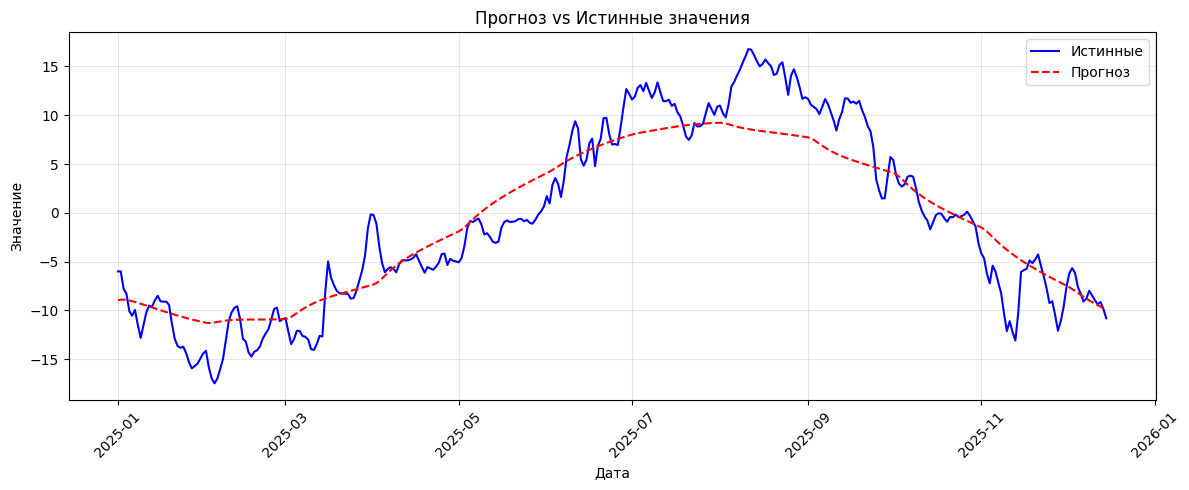

     48-1 (0,5)
RMSE   2.228773
MAE    1.711081
ME     -0.20973
NSE    0.898846


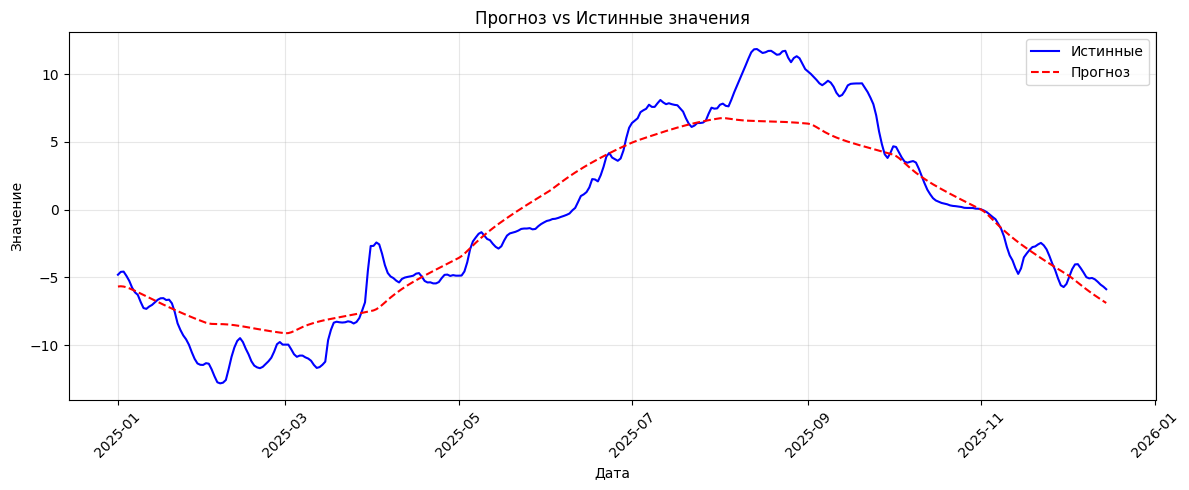

      48-1 (1)
RMSE  1.771606
MAE   1.366933
ME   -0.088016
NSE   0.892907


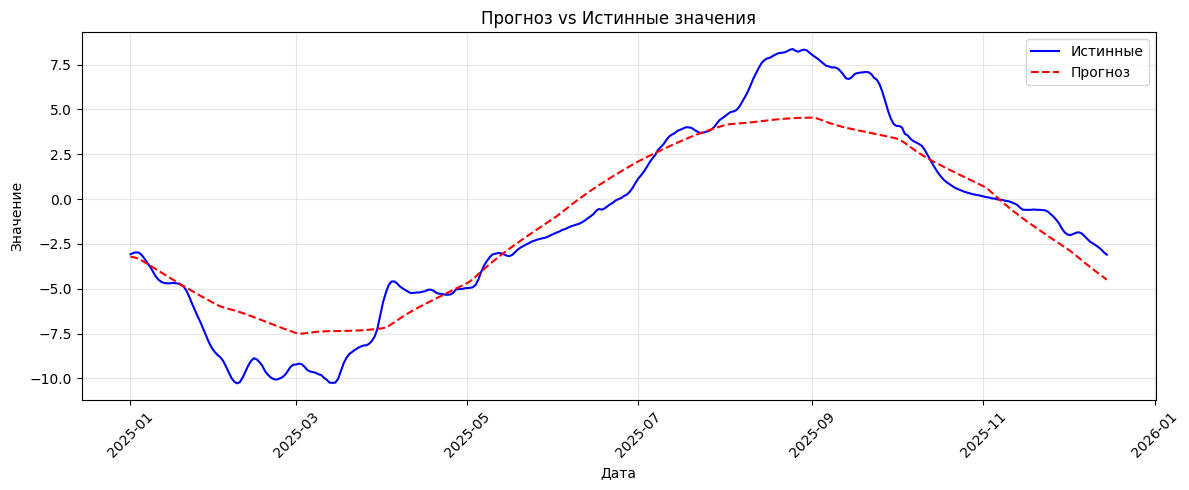

     48-1 (1,5)
RMSE   1.441503
MAE    1.139766
ME     -0.12506
NSE    0.891749


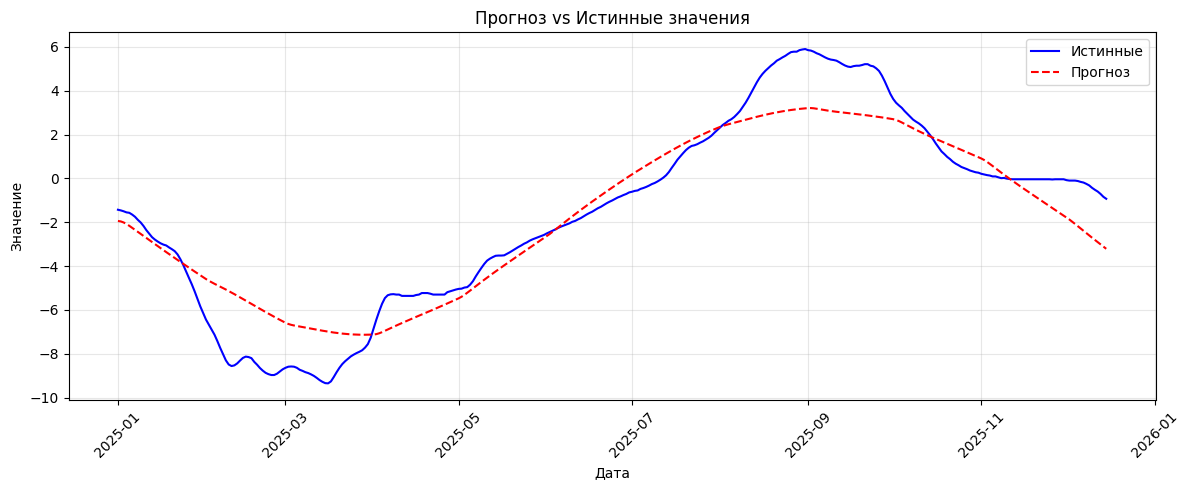

      48-1 (2)
RMSE  1.167916
MAE   0.919201
ME    0.004899
NSE    0.88909


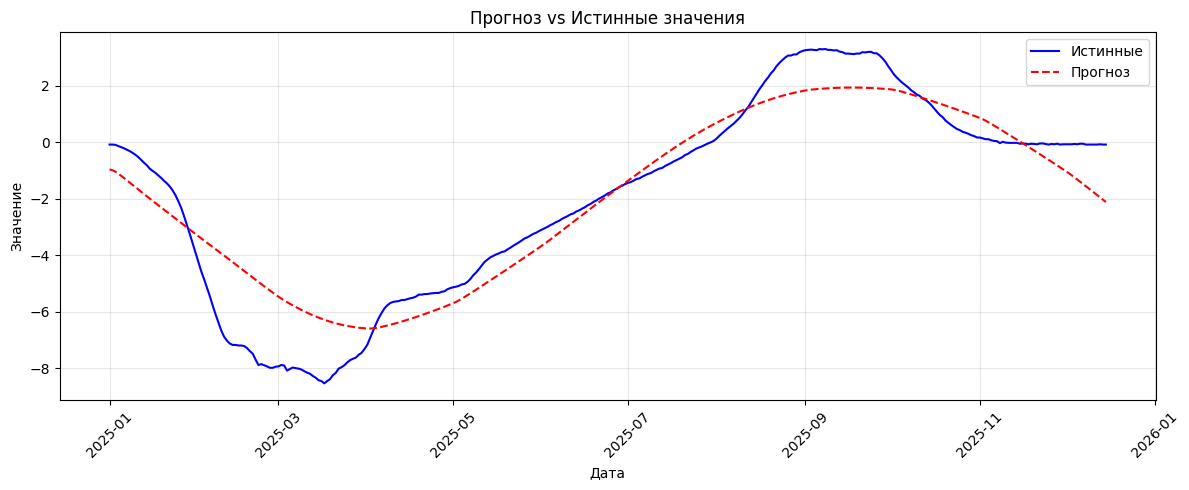

     48-1 (2,5)
RMSE   1.018271
MAE     0.77312
ME    -0.180406
NSE    0.864893


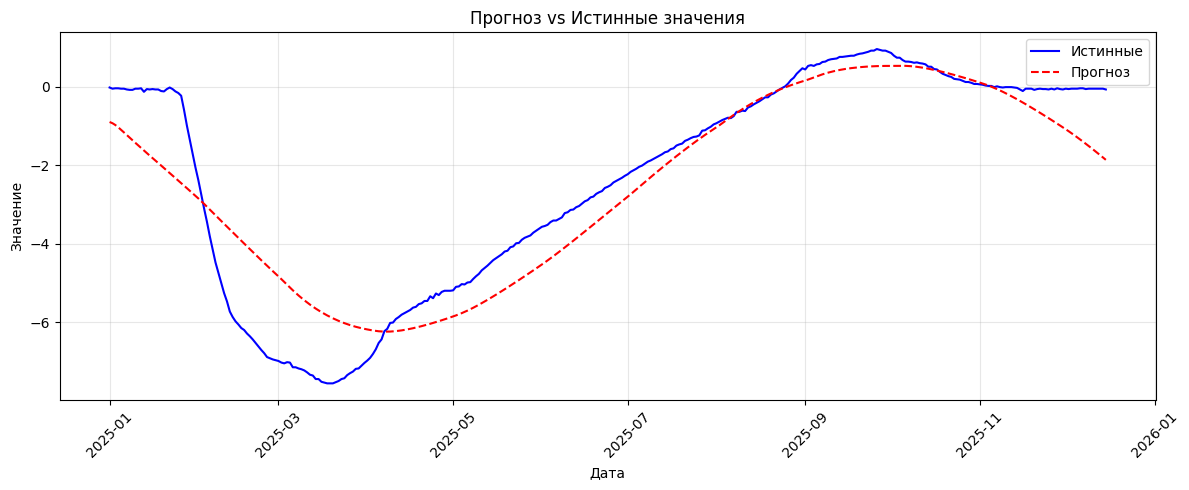

      48-1 (3)
RMSE  0.883072
MAE   0.666115
ME   -0.010418
NSE   0.869074


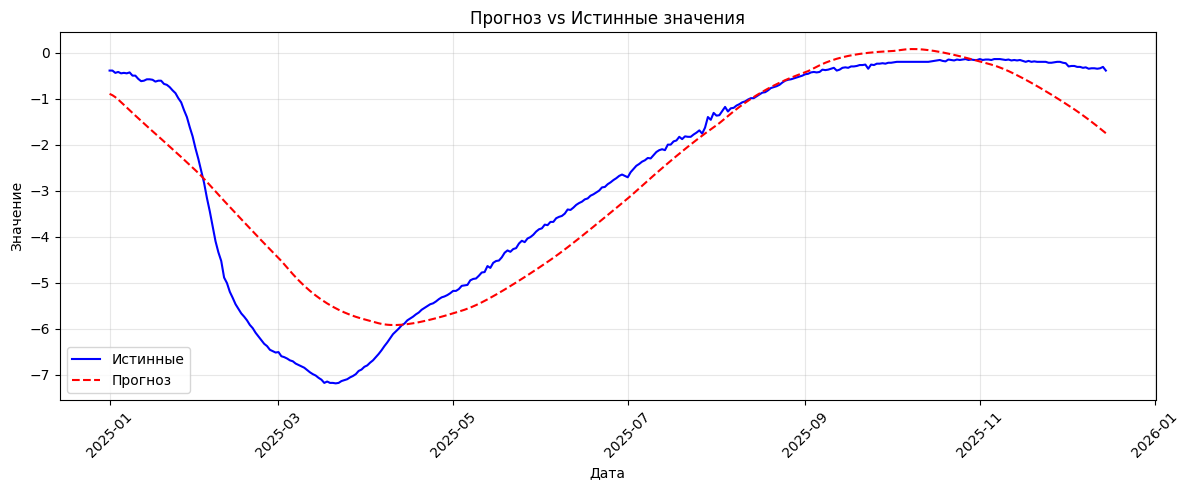

     48-1 (3,5)
RMSE   0.737701
MAE    0.588676
ME    -0.155874
NSE    0.891065


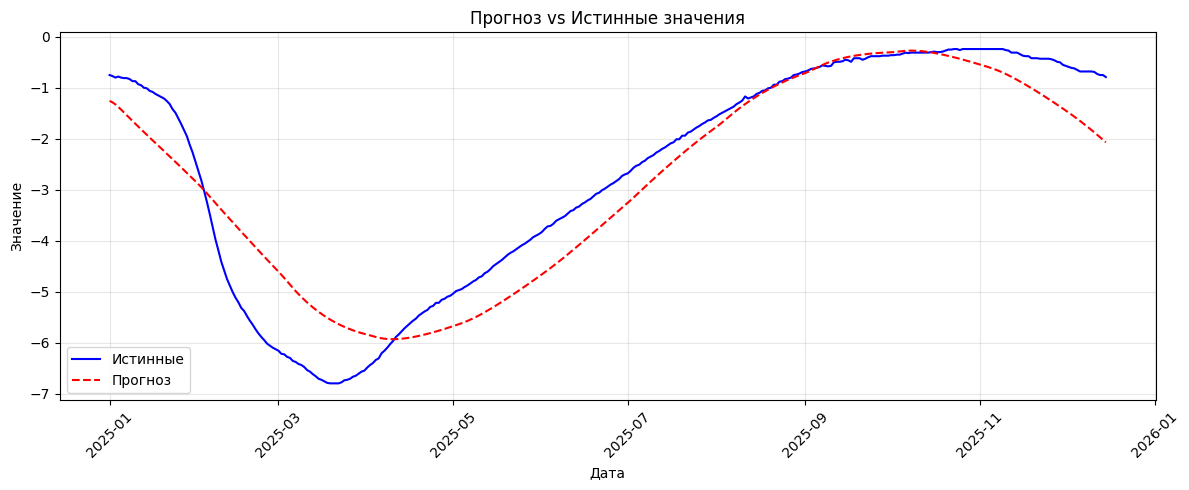

      48-1 (4)
RMSE  0.612145
MAE   0.478879
ME   -0.069678
NSE   0.908636


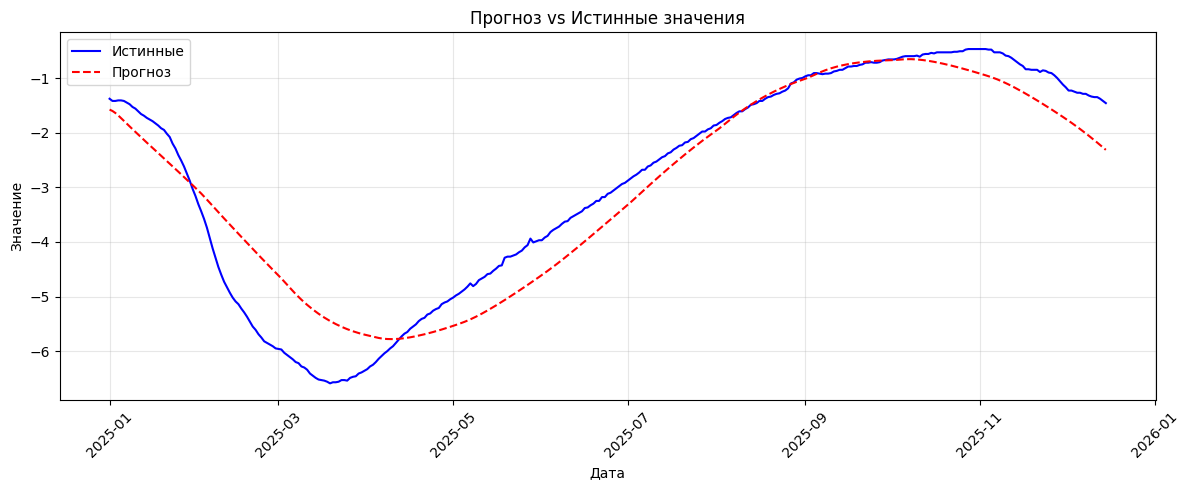

     48-1 (4,5)
RMSE   0.613071
MAE    0.542755
ME    -0.252157
NSE     0.89884


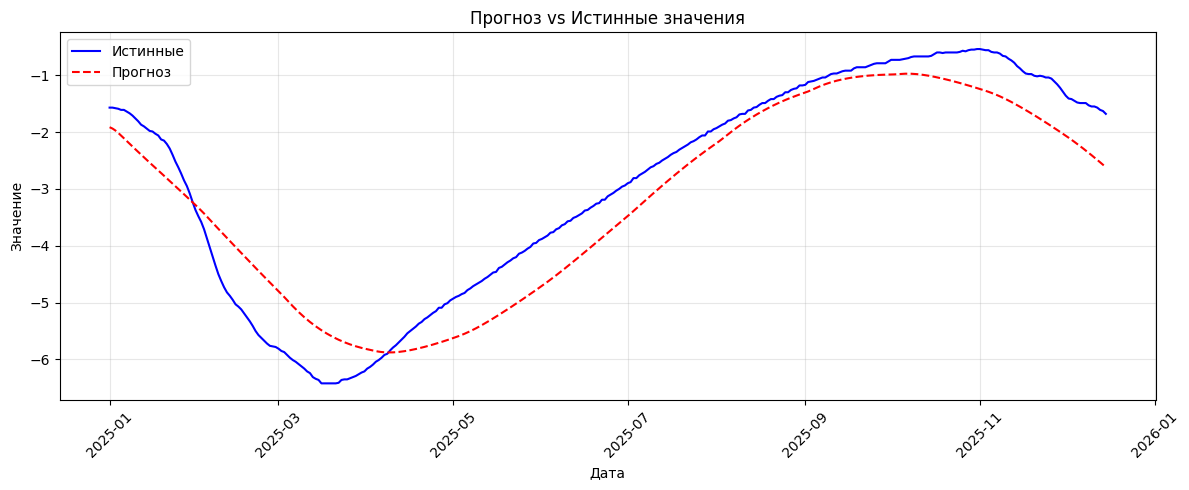

      48-1 (5)
RMSE  0.526274
MAE   0.420746
ME   -0.075451
NSE   0.917657


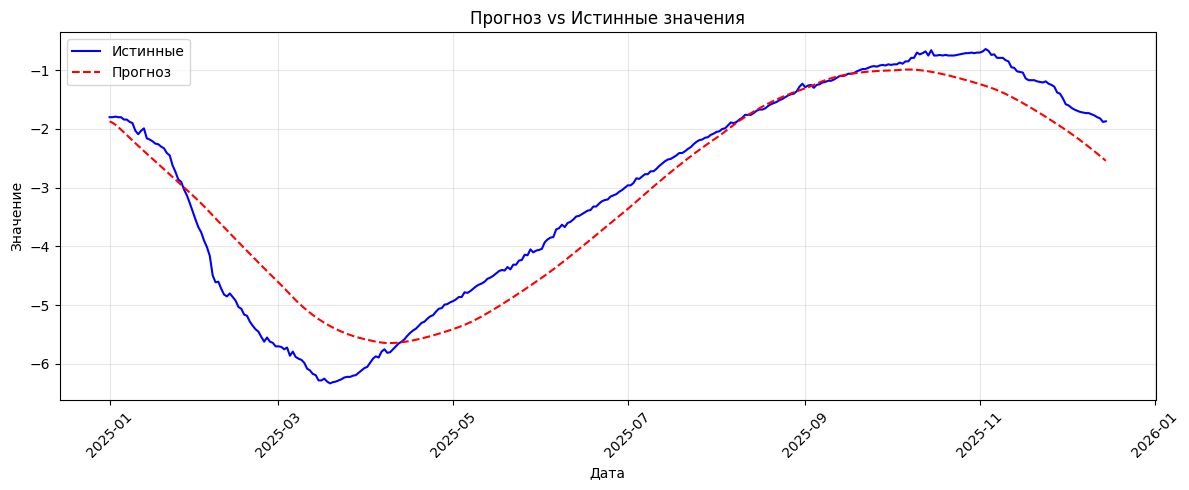

      48-1 (6)
RMSE  0.516037
MAE   0.431906
ME   -0.158478
NSE   0.905262


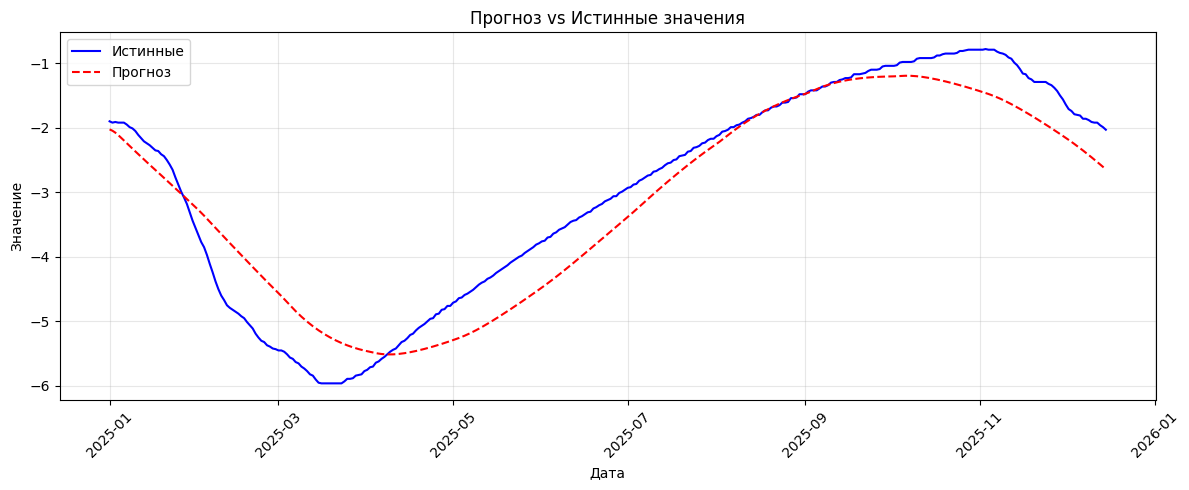

      48-1 (7)
RMSE   0.45756
MAE   0.382084
ME    -0.11733
NSE   0.909097


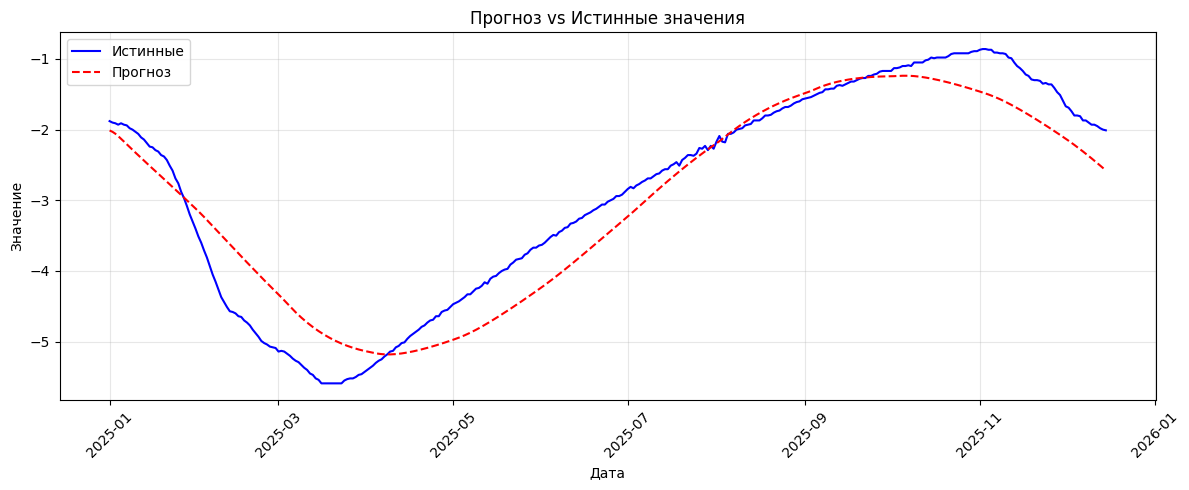

      48-1 (8)
RMSE  0.400644
MAE   0.328126
ME   -0.056079
NSE   0.908014


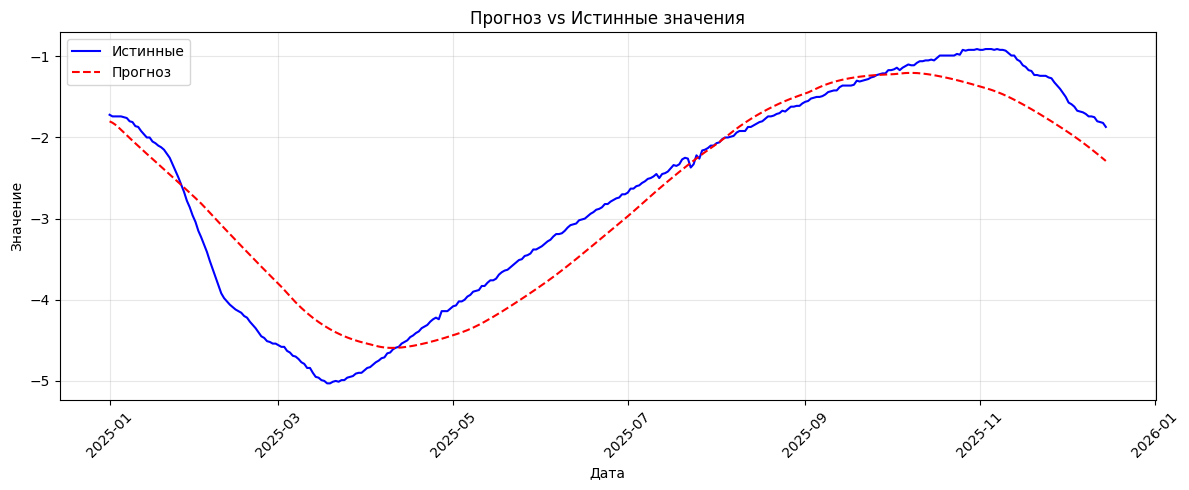

      48-1 (9)
RMSE  0.311736
MAE   0.246179
ME    0.034751
NSE   0.916303


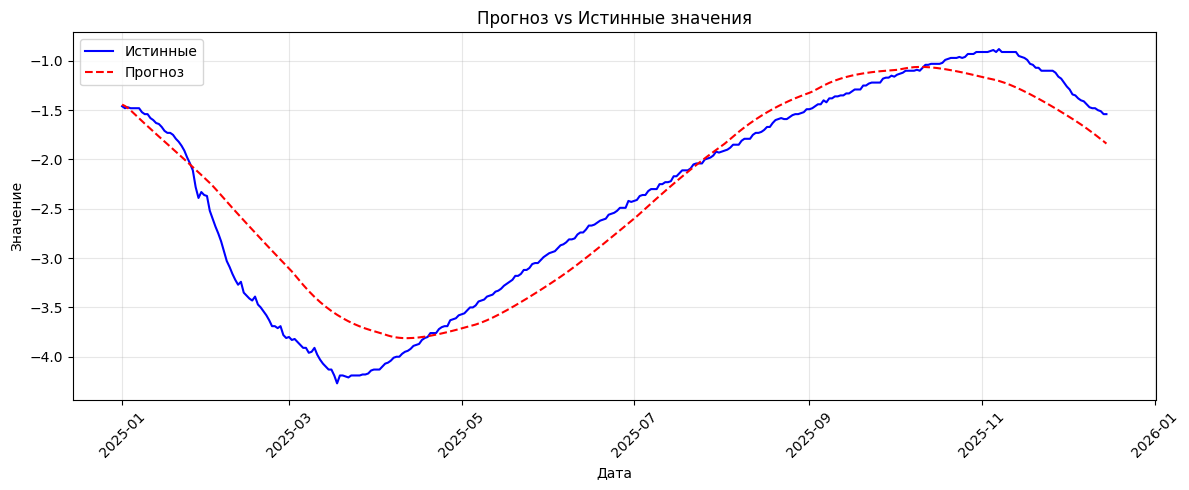

     48-1 (10)
RMSE  0.246558
MAE    0.18338
ME    0.075542
NSE   0.914632


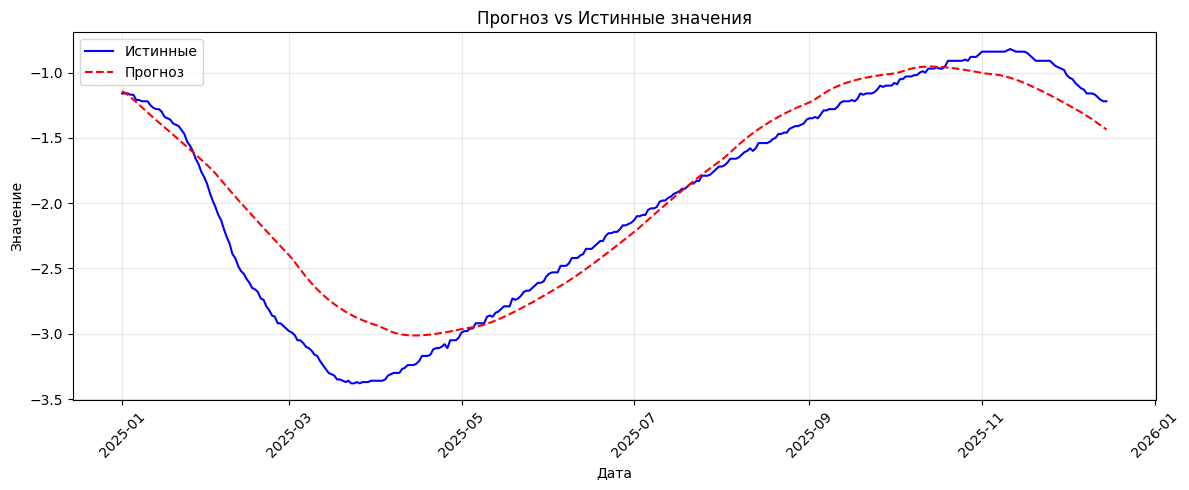

In [15]:
test_start = df_train_full[-lags_length:]

y_pred = get_full_predict(
    model=model,
    df_test=df_test,
    test_start=test_start,
    feature_scaler=feature_scaler,
    target_scaler=target_scaler,
    features_cols=features_cols,
    target_cols=target_cols,
    device=device
)
y_true = df_test[target_cols].values

eval_dict = evaluate(y_true, y_pred)
print(pd.DataFrame(eval_dict, index=['Значение для всех глубин']))

eval_by_depth_df = evaluate_by_depth(y_true, y_pred, target_cols)
for i, col in enumerate(target_cols):
    metrics = eval_by_depth_df.loc[col]
    print(metrics.to_frame()[1:])
    
    s_true = pd.Series(y_true[:, i], index=df_test.index)
    s_pred = pd.Series(y_pred[:, i], index=df_test.index)
    
    plot_forecast(pd.DataFrame(s_true), pd.DataFrame(s_pred))